# Why Not Measure From the Origin (0, 0)?

Why do we measure rise and run from the CENTER (averages) instead of from (0, 0)?

## Chapter 1: What IS the origin?
The origin is the point (0, 0) — where both axes start.

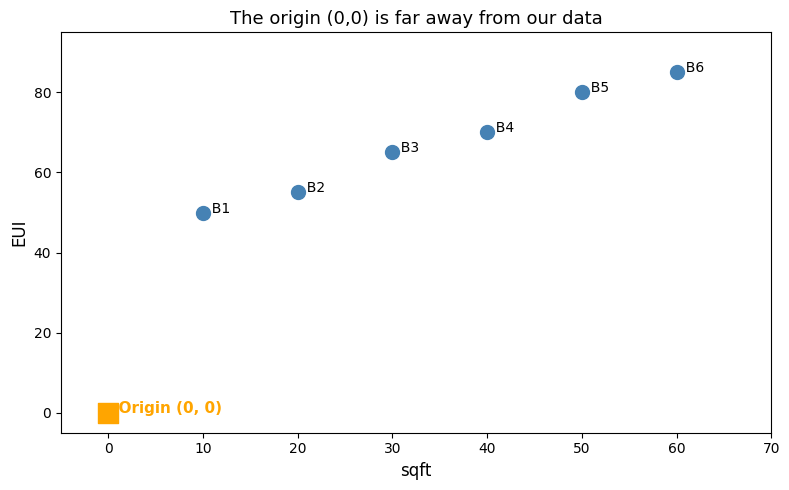

The origin is at (0, 0).
Our data is clustered around sqft=35, EUI=67.
The origin is nowhere near our data.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

sqft = np.array([10, 20, 30, 40, 50, 60], dtype=float)
eui  = np.array([50, 55, 65, 70, 80, 85], dtype=float)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sqft, eui, color='steelblue', s=100, zorder=5)
ax.scatter(0, 0, color='orange', s=200, marker='s', zorder=5)
ax.annotate('  Origin (0, 0)', xy=(0, 0), fontsize=11, color='orange', fontweight='bold')

for i in range(len(sqft)):
    ax.annotate(f'  B{i+1}', xy=(sqft[i], eui[i]), fontsize=10)

ax.set_xlim(-5, 70)
ax.set_ylim(-5, 95)
ax.set_xlabel('sqft', fontsize=12)
ax.set_ylabel('EUI', fontsize=12)
ax.set_title('The origin (0,0) is far away from our data', fontsize=13)
plt.tight_layout()
plt.show()

print('The origin is at (0, 0).')
print('Our data is clustered around sqft=35, EUI=67.')
print('The origin is nowhere near our data.')

## Chapter 2: What happens if we use the origin?

In [2]:
# Slope from origin: every point's run = sqft, rise = eui (measured from 0,0)
# slope = sum(sqft * eui) / sum(sqft²)

slope_from_origin = (sqft * eui).sum() / (sqft ** 2).sum()

# Slope from center (the correct way)
avg_sqft = sqft.mean()
avg_eui = eui.mean()
runs = sqft - avg_sqft
rises = eui - avg_eui
slope_from_center = (runs * rises).sum() / (runs ** 2).sum()
intercept_center = avg_eui - slope_from_center * avg_sqft

print('Slope from origin:   ', round(slope_from_origin, 4))
print('Slope from center:   ', round(slope_from_center, 4))
print()
print('Different numbers! Let\'s see which line fits better.')

Slope from origin:    1.6978
Slope from center:    0.7286

Different numbers! Let's see which line fits better.


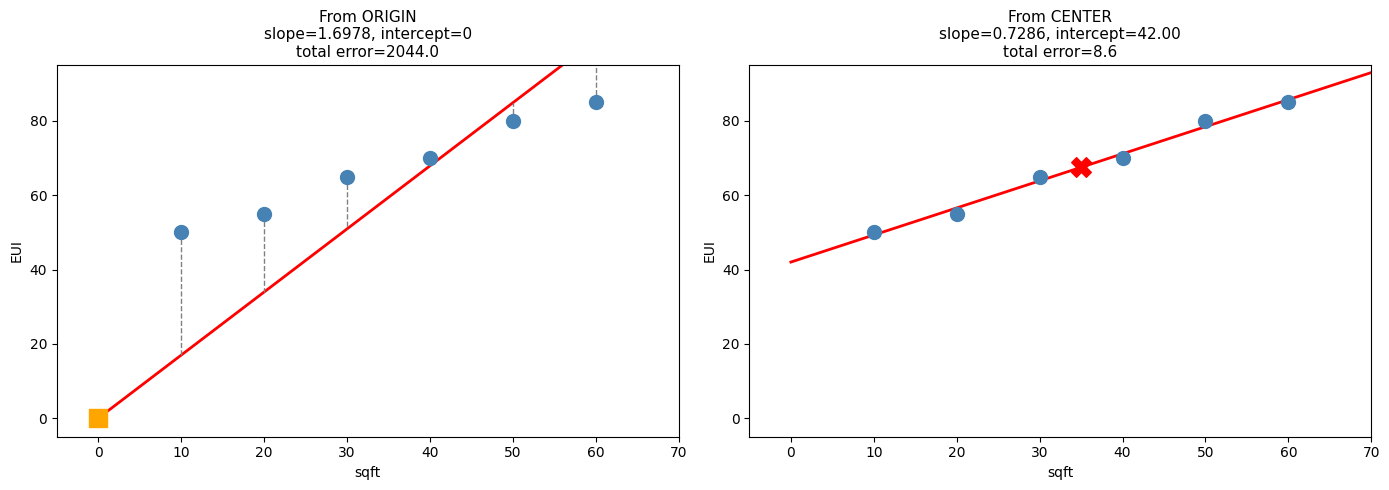

Error from origin: 2044.0
Error from center: 8.6

The center method has much lower error!


In [3]:
# Draw both lines
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_line = np.linspace(0, 70, 100)

# From origin: line MUST pass through (0,0), so intercept = 0
ax = axes[0]
pred_origin = slope_from_origin * sqft  # no intercept
error_origin = ((eui - pred_origin) ** 2).sum()
ax.scatter(sqft, eui, color='steelblue', s=100, zorder=5)
ax.scatter(0, 0, color='orange', s=150, marker='s', zorder=5)
ax.plot(x_line, slope_from_origin * x_line, color='red', linewidth=2)
for i in range(len(sqft)):
    ax.plot([sqft[i], sqft[i]], [eui[i], pred_origin[i]], 'gray', linestyle='--', linewidth=1)
ax.set_title(f'From ORIGIN\nslope={slope_from_origin:.4f}, intercept=0\ntotal error={error_origin:.1f}', fontsize=11)
ax.set_xlabel('sqft')
ax.set_ylabel('EUI')
ax.set_xlim(-5, 70)
ax.set_ylim(-5, 95)

# From center: line passes through center, has a free intercept
ax = axes[1]
pred_center = slope_from_center * sqft + intercept_center
error_center = ((eui - pred_center) ** 2).sum()
ax.scatter(sqft, eui, color='steelblue', s=100, zorder=5)
ax.scatter(avg_sqft, avg_eui, color='red', s=200, marker='X', zorder=5)
ax.plot(x_line, slope_from_center * x_line + intercept_center, color='red', linewidth=2)
for i in range(len(sqft)):
    ax.plot([sqft[i], sqft[i]], [eui[i], pred_center[i]], 'gray', linestyle='--', linewidth=1)
ax.set_title(f'From CENTER\nslope={slope_from_center:.4f}, intercept={intercept_center:.2f}\ntotal error={error_center:.1f}', fontsize=11)
ax.set_xlabel('sqft')
ax.set_ylabel('EUI')
ax.set_xlim(-5, 70)
ax.set_ylim(-5, 95)

plt.tight_layout()
plt.show()

print(f'Error from origin: {error_origin:.1f}')
print(f'Error from center: {error_center:.1f}')
print()
print('The center method has much lower error!')

## Chapter 3: WHY is the origin worse?
The origin forces the line through (0, 0). That's a constraint that doesn't match reality.

In [4]:
# The origin says: a building with 0 sqft uses 0 energy.
# The center says: a building with 0 sqft uses [intercept] energy.

print('What does each method say about a building with 0 sqft?')
print()
print(f'Origin method:  EUI = {slope_from_origin:.4f} x 0 = 0')
print(f'Center method:  EUI = {slope_from_center:.4f} x 0 + {intercept_center:.2f} = {intercept_center:.2f}')
print()
print('The origin FORCES the prediction to be 0 when sqft is 0.')
print('But who cares about a 0 sqft building? That doesn\'t exist!')
print()
print('By forcing the line through (0,0), we\'re wasting our line\'s freedom.')
print('The line has to stretch from (0,0) all the way to our data.')
print('That stretch pulls it away from where it should be.')

What does each method say about a building with 0 sqft?

Origin method:  EUI = 1.6978 x 0 = 0
Center method:  EUI = 0.7286 x 0 + 42.00 = 42.00

The origin FORCES the prediction to be 0 when sqft is 0.
But who cares about a 0 sqft building? That doesn't exist!

By forcing the line through (0,0), we're wasting our line's freedom.
The line has to stretch from (0,0) all the way to our data.
That stretch pulls it away from where it should be.


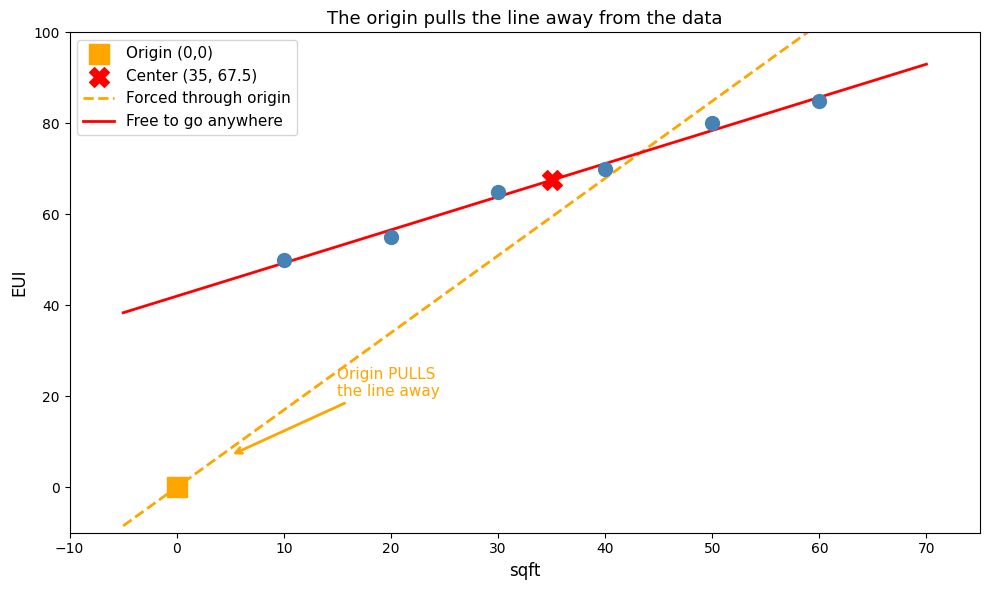

The orange line has to start at (0,0) — it's locked there.
The red line is free — it goes wherever fits the data best.


In [5]:
# Visual: the origin pulls the line away
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(sqft, eui, color='steelblue', s=100, zorder=5)
ax.scatter(0, 0, color='orange', s=200, marker='s', zorder=5, label='Origin (0,0)')
ax.scatter(avg_sqft, avg_eui, color='red', s=200, marker='X', zorder=5, label='Center (35, 67.5)')

x_line = np.linspace(-5, 70, 100)
ax.plot(x_line, slope_from_origin * x_line, color='orange', linewidth=2, 
        linestyle='--', label=f'Forced through origin')
ax.plot(x_line, slope_from_center * x_line + intercept_center, color='red', linewidth=2,
        label=f'Free to go anywhere')

# Arrow showing the pull
ax.annotate('Origin PULLS\nthe line away', xy=(5, 7), xytext=(15, 20),
            fontsize=11, color='orange',
            arrowprops=dict(arrowstyle='->', color='orange', lw=2))

ax.legend(fontsize=11)
ax.set_xlim(-10, 75)
ax.set_ylim(-10, 100)
ax.set_xlabel('sqft', fontsize=12)
ax.set_ylabel('EUI', fontsize=12)
ax.set_title('The origin pulls the line away from the data', fontsize=13)
plt.tight_layout()
plt.show()

print('The orange line has to start at (0,0) — it\'s locked there.')
print('The red line is free — it goes wherever fits the data best.')

## Chapter 4: A case where it REALLY matters

In [6]:
# Real buildings: sqft in thousands, EUI around 50-100
# The data is far from the origin

real_sqft = np.array([20000, 35000, 50000, 65000, 80000, 95000], dtype=float)
real_eui  = np.array([90, 82, 75, 68, 60, 55], dtype=float)  # downward trend

avg_real_sqft = real_sqft.mean()
avg_real_eui = real_eui.mean()

# From origin
origin_slope = (real_sqft * real_eui).sum() / (real_sqft ** 2).sum()

# From center
real_runs = real_sqft - avg_real_sqft
real_rises = real_eui - avg_real_eui
center_slope = (real_runs * real_rises).sum() / (real_runs ** 2).sum()
center_intercept = avg_real_eui - center_slope * avg_real_sqft

print(f'Origin slope:  {origin_slope:.6f}  (POSITIVE — says bigger = more energy)')
print(f'Center slope:  {center_slope:.6f}  (NEGATIVE — says bigger = less energy)')
print()
print('They don\'t even agree on the DIRECTION!')

Origin slope:  0.000962  (POSITIVE — says bigger = more energy)
Center slope:  -0.000472  (NEGATIVE — says bigger = less energy)

They don't even agree on the DIRECTION!


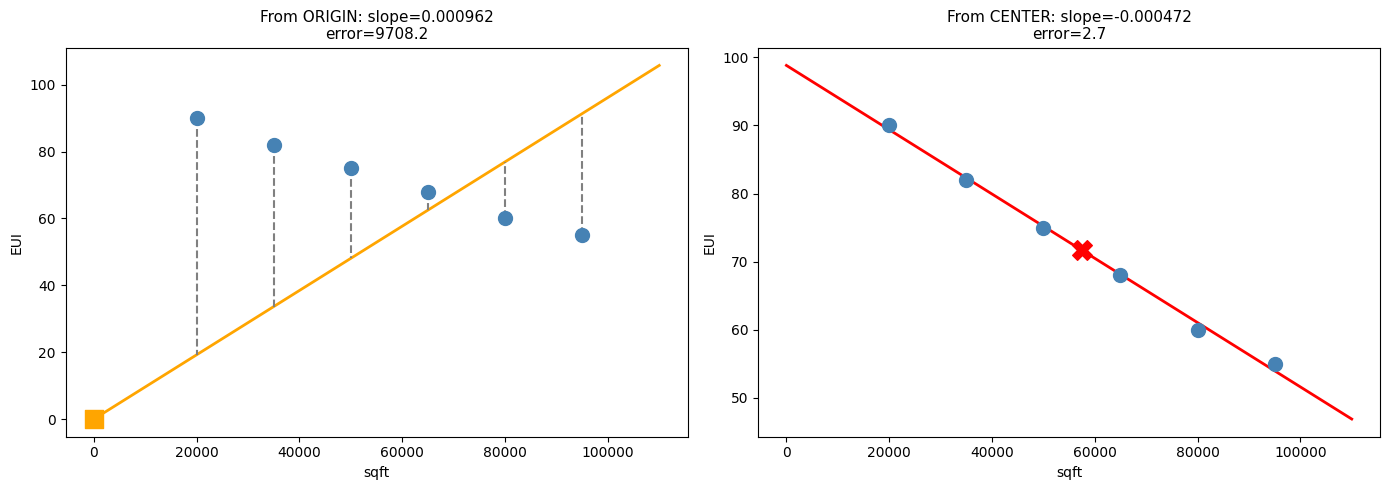

The data goes DOWNHILL — bigger buildings use less energy per sqft.
Origin method: slope is POSITIVE (0.000962) — wrong direction!
Center method: slope is NEGATIVE (-0.000472) — correct!

The origin is so far from the data that it completely distorts the slope.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_line = np.linspace(0, 110000, 100)

# Origin
ax = axes[0]
pred_o = origin_slope * real_sqft
err_o = ((real_eui - pred_o) ** 2).sum()
ax.scatter(real_sqft, real_eui, color='steelblue', s=100, zorder=5)
ax.scatter(0, 0, color='orange', s=150, marker='s', zorder=5)
ax.plot(x_line, origin_slope * x_line, color='orange', linewidth=2)
for i in range(len(real_sqft)):
    ax.plot([real_sqft[i], real_sqft[i]], [real_eui[i], pred_o[i]], 'gray', linestyle='--')
ax.set_title(f'From ORIGIN: slope={origin_slope:.6f}\nerror={err_o:.1f}', fontsize=11)
ax.set_xlabel('sqft')
ax.set_ylabel('EUI')

# Center
ax = axes[1]
pred_c = center_slope * real_sqft + center_intercept
err_c = ((real_eui - pred_c) ** 2).sum()
ax.scatter(real_sqft, real_eui, color='steelblue', s=100, zorder=5)
ax.scatter(avg_real_sqft, avg_real_eui, color='red', s=200, marker='X', zorder=5)
ax.plot(x_line, center_slope * x_line + center_intercept, color='red', linewidth=2)
for i in range(len(real_sqft)):
    ax.plot([real_sqft[i], real_sqft[i]], [real_eui[i], pred_c[i]], 'gray', linestyle='--')
ax.set_title(f'From CENTER: slope={center_slope:.6f}\nerror={err_c:.1f}', fontsize=11)
ax.set_xlabel('sqft')
ax.set_ylabel('EUI')

plt.tight_layout()
plt.show()

print('The data goes DOWNHILL — bigger buildings use less energy per sqft.')
print(f'Origin method: slope is POSITIVE ({origin_slope:.6f}) — wrong direction!')
print(f'Center method: slope is NEGATIVE ({center_slope:.6f}) — correct!')
print()
print('The origin is so far from the data that it completely distorts the slope.')

## Chapter 5: The center is special
Why the center specifically, and not some other reference point?

In [8]:
# Let's try different reference points and see which gives the lowest error

sqft = np.array([10, 20, 30, 40, 50, 60], dtype=float)
eui  = np.array([50, 55, 65, 70, 80, 85], dtype=float)
avg_sqft = sqft.mean()
avg_eui = eui.mean()

ref_points = [
    (0, 0, 'Origin'),
    (10, 50, 'First point (B1)'),
    (60, 85, 'Last point (B6)'),
    (avg_sqft, avg_eui, 'CENTER (averages)'),
]

print('Trying different reference points:')
print()
print(f'{"Reference point":<25} | slope  | intercept | total error')
print('-' * 70)

best_error = float('inf')
for ref_x, ref_y, name in ref_points:
    r = sqft - ref_x
    ri = eui - ref_y
    if (r ** 2).sum() == 0:
        continue
    s = (r * ri).sum() / (r ** 2).sum()
    b = ref_y - s * ref_x
    pred = s * sqft + b
    err = ((eui - pred) ** 2).sum()
    marker = '  <-- LOWEST' if name == 'CENTER (averages)' else ''
    print(f'{name:<25} | {s:.4f} | {b:9.2f} | {err:.2f}{marker}')

print()
print('The CENTER always gives the lowest error.')
print('That\'s not a coincidence — it\'s mathematically guaranteed.')
print()
print('The center is the one point that\'s equally "close" to all data points.')
print('Any other reference point is biased toward some points and away from others.')

Trying different reference points:

Reference point           | slope  | intercept | total error
----------------------------------------------------------------------
Origin                    | 1.6978 |      0.00 | 2043.96
First point (B1)          | 0.7091 |     42.91 | 9.55
Last point (B6)           | 0.7091 |     42.45 | 9.55
CENTER (averages)         | 0.7286 |     42.00 | 8.57  <-- LOWEST

The CENTER always gives the lowest error.
That's not a coincidence — it's mathematically guaranteed.

The center is the one point that's equally "close" to all data points.
Any other reference point is biased toward some points and away from others.


## Summary

1. **The origin (0, 0) is arbitrary.** It has nothing to do with your data. Using it forces the line to pass through a point that doesn't matter.

2. **The further your data is from the origin, the worse it gets.** Real buildings have sqft in the thousands and EUI around 50-100. The origin is nowhere near that. Using it can even give the WRONG direction for the slope.

3. **The center (averages) is the natural reference point.** It sits right in the middle of your data. Measuring from the center gives the lowest possible error — mathematically guaranteed.

4. **The intercept handles the rest.** By measuring from the center and then computing an intercept, the line is free to land wherever it fits best. The origin locks the line to (0, 0) for no good reason.